##**k-Nearest Neighbors (k-NN)**

En este noteboock se utilizará como clasificador k-Nearest Neighbors (k-NN)

In [21]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from skimage.feature import local_binary_pattern
from skimage.color import rgb2gray

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, auc,
                             roc_auc_score, classification_report, confusion_matrix, roc_curve, precision_recall_fscore_support)
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix

from sklearn.pipeline import Pipeline

import joblib

In [3]:
from google.colab import drive
import glob
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/lungcropped"

train_normal = glob.glob(os.path.join(DATASET_PATH, "train/NORMAL/*.jpeg"))
train_pneu   = glob.glob(os.path.join(DATASET_PATH, "train/PNEUMONIA/*.jpeg"))

test_normal = glob.glob(os.path.join(DATASET_PATH, "test/NORMAL/*.jpeg"))
test_pneu   = glob.glob(os.path.join(DATASET_PATH, "test/PNEUMONIA/*.jpeg"))

val_normal = glob.glob(os.path.join(DATASET_PATH, "val/NORMAL/*.jpeg"))
val_pneu   = glob.glob(os.path.join(DATASET_PATH, "val/PNEUMONIA/*.jpeg"))

print("NORMAL train:", len(train_normal))
print("PNEUMONIA train:", len(train_pneu))

print("NORMAL test:", len(test_normal))
print("PNEUMONIA test:", len(test_pneu))

print("NORMAL val:", len(val_normal))
print("PNEUMONIA val:", len(val_pneu))

Mounted at /content/drive
NORMAL train: 1341
PNEUMONIA train: 3875
NORMAL test: 234
PNEUMONIA test: 390
NORMAL val: 8
PNEUMONIA val: 8


##Estructura de datos

In [4]:
#Cargar descriptores de contorno

contour_train = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_train.npz")
contour_test= np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_test.npz")
contour_val= np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/contour_val.npz")

# Cargar LBP normal
lbp_normal_train = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_train.npz")
lbp_normal_test  = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_test.npz")
lbp_normal_val   = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_normal_val.npz")

# Cargar LBP Neumonía
lbp_pneu_train = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_train.npz")
lbp_pneu_test  = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_test.npz")
lbp_pneu_val   = np.load("/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_pneu_val.npz")



##Función para combinar normal + pneu LBP

In [5]:
def merge_npz(normal, pneu, output_Path):
    X_normal = normal['features']
    files_normal = normal['filenames']

    X_pneu = pneu['features']
    files_pneu = pneu['filenames']

    # Numerical labels
    y_normal = np.zeros(len(X_normal))   # 0 = NORMAL
    y_pneu = np.ones(len(X_pneu))        # 1 = PNEUMONIA

    # Merge everything
    X = np.concatenate([X_normal, X_pneu], axis=0)
    y = np.concatenate([y_normal, y_pneu], axis=0)
    files = np.concatenate([files_normal, files_pneu], axis=0)

    # Save into one merged .npz
    np.savez(output_Path, X=X, y=y, files=files)
    print("Merged file saved as:", output_Path)


##Generar archivos LBP combinados (train, test, val)

In [6]:
merge_npz(lbp_normal_test, lbp_pneu_test,
          "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_test.npz")

merge_npz(lbp_normal_train, lbp_pneu_train,
          "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_train.npz")

merge_npz(lbp_normal_val, lbp_pneu_val,
          "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_val.npz")

#Cargar y revisar los archivos combinados

path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_val.npz"
lbp_merged_val = np.load(path)

path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_train.npz"
lbp_merged_train = np.load(path)

path = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_test.npz"
lbp_merged_test = np.load(path)

check_npz("lbp_merged_val", lbp_merged_val)
check_npz("lbp_merged_train", lbp_merged_train)
check_npz("lbp_merged_test", lbp_merged_test)


Merged file saved as: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_test.npz
Merged file saved as: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_train.npz
Merged file saved as: /content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features/lbp_merged_val.npz


NameError: name 'check_npz' is not defined

Shapes (train, val, test): (5216, 58) (16, 58) (624, 58)
Labels distribution train: [1341 3875]
Labels distribution val: [8 8]
Labels distribution test: [234 390]
K candidates for SelectKBest: [10, 20, 50, 58]

== Evaluando SelectKBest k = 10
 Mejores params (k=10): {'n_neighbors': 15, 'p': 2, 'weights': 'distance'}  (ROC AUC 0.8820)

== Evaluando SelectKBest k = 20
 Mejores params (k=20): {'n_neighbors': 15, 'p': 2, 'weights': 'distance'}  (ROC AUC 0.9144)

== Evaluando SelectKBest k = 50
 Mejores params (k=50): {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}  (ROC AUC 0.9228)

== Evaluando SelectKBest k = 58
 Mejores params (k=58): {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}  (ROC AUC 0.9242)

-> Mejor k seleccionado: 58 con ROC AUC (CV): 0.9241641057215422

[VAL]  Accuracy: 0.7500
[VAL]  Precision: 0.7000  Recall: 0.8750  F1: 0.7778
[VAL]  Classification report:
               precision    recall  f1-score   support

         0.0     0.8333    0.6250    0.7143         8
  

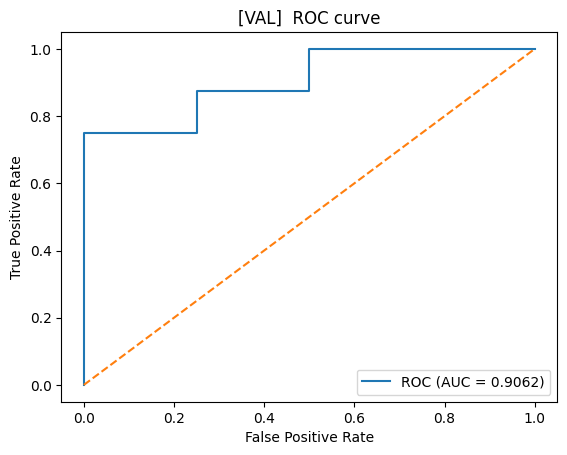


[TEST]  Accuracy: 0.6987
[TEST]  Precision: 0.6898  Recall: 0.9410  F1: 0.7961
[TEST]  Classification report:
               precision    recall  f1-score   support

         0.0     0.7500    0.2949    0.4233       234
         1.0     0.6898    0.9410    0.7961       390

    accuracy                         0.6987       624
   macro avg     0.7199    0.6179    0.6097       624
weighted avg     0.7124    0.6987    0.6563       624

[TEST]  Confusion matrix:
 [[ 69 165]
 [ 23 367]]
[TEST]  ROC AUC: 0.7642


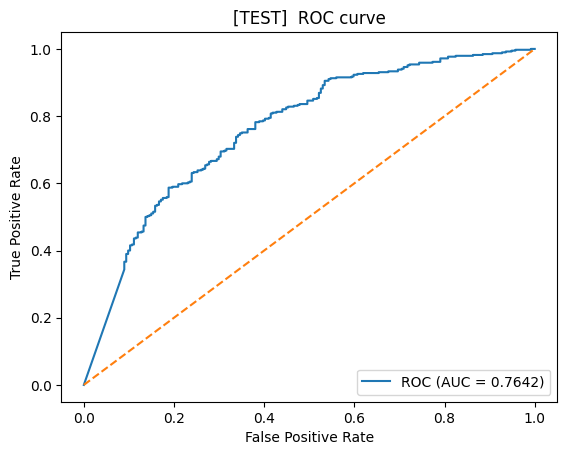

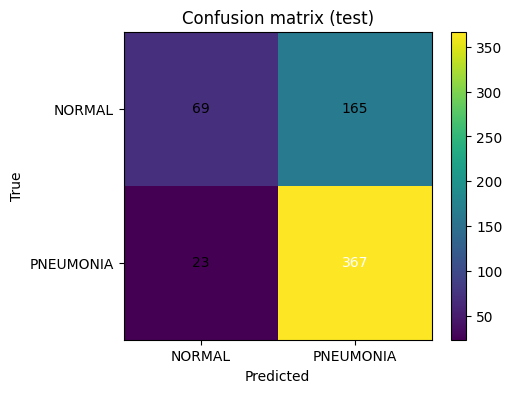


Top 20 features según SelectKBest (f score):
    feature_idx     f_score        p_value
0            41  561.454009  5.734907e-118
1            42  554.533912  1.313293e-116
2            57  550.115825  9.714224e-116
3            38  521.032227  5.311449e-110
4            39  511.053423  5.020439e-108
5            43  497.584504  2.359413e-105
6            40  432.126884   2.827283e-92
7            55  425.678885   5.599034e-91
8            37  425.413965   6.330285e-91
9            54  404.573832   1.007456e-86
10            7  344.132393   1.911792e-74
11            9  331.136064   8.704187e-72
12           44  325.297590   1.367939e-70
13           19  319.749419   1.879964e-69
14           17  306.525156   9.809974e-67
15            1  298.234319   4.999247e-65
16           36  280.533103   2.254548e-61
17           20  272.390639   1.091872e-59
18           16  260.701130   2.897721e-57
19           18  230.595537   5.376712e-51
Modelo guardado en: /content/drive/MyDrive/TareasDi

In [7]:
# ================================
# UTIL: cargar .npz robustamente
# ================================
def load_npz_any(path):
    """Carga un .npz y devuelve (X, y, files) intentando varias convenciones."""
    npz = np.load(path, allow_pickle=True)
    keys = list(npz.keys())

    # common variants:

    if 'X' in keys and 'y' in keys and ('files' in keys or 'filenames' in keys):
        X = npz['X']
        y = npz['y']
        files = npz['files'] if 'files' in keys else npz['filenames']
        return X, y, np.array(files, dtype=str)
    if 'features' in keys:
        X = npz['features']
        files = npz['filenames'] if 'filenames' in keys else (npz['files'] if 'files' in keys else None)

        # try to get y either from file or from 'y'

        if 'y' in keys:
            y = npz['y']
        else:

            # try infer y from filenames (NORMAL / PNEUMONIA) if filenames present

            if files is not None:
                files = np.array(files, dtype=str)
                y = np.array([0 if ('NORMAL' in os.path.basename(f).upper()) else 1 for f in files])
            else:
                raise ValueError(f"No 'y' found and cannot infer from filenames in {path}")
        return X, y, np.array(files, dtype=str)

    # fallback: if file contains a single array, assume X and no labels

    if len(keys) == 1:
        X = npz[keys[0]]
        raise ValueError(f"{path} contains only features ({keys[0]}) — no labels found. Expected X+y+files or features+filenames.")
    raise ValueError(f"Formato NPZ desconocido para {path} — keys: {keys}")

base = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features"

lbp_merged_train_path = os.path.join(base, "lbp_merged_train.npz")
lbp_merged_val_path   = os.path.join(base, "lbp_merged_val.npz")
lbp_merged_test_path  = os.path.join(base, "lbp_merged_test.npz")

contour_train_path = os.path.join(base, "contour_train.npz")
contour_val_path   = os.path.join(base, "contour_val.npz")
contour_test_path  = os.path.join(base, "contour_test.npz")

# CARGA y ALIGN (por filenames)

def align_and_merge(lbp_path, contour_path):
    """
    Carga lbp (merged) y contour (puede ser features+filenames) y devuelve
    X_combined, y_aligned, files_aligned. Se hace match por basename de filename.
    """
    X1, y1, files1 = load_npz_any(lbp_path)       # lbp merged: X,y,files
    X2, y2, files2 = load_npz_any(contour_path)   # contour: features,(y or infers)
    # Normalize filenames to basename for matching
    b1 = np.array([os.path.basename(f) for f in files1], dtype=str)
    b2 = np.array([os.path.basename(f) for f in files2], dtype=str)

    # build index maps
    idx1 = {name: i for i, name in enumerate(b1)}
    idx2 = {name: i for i, name in enumerate(b2)}

    # intersection
    common = sorted(set(b1).intersection(set(b2)))
    if len(common) == 0:
        raise ValueError("No hay archivos comunes entre LBP y contour. Revisa filenames.")
    # collect aligned arrays
    inds1 = [idx1[name] for name in common]
    inds2 = [idx2[name] for name in common]

    X_lbp_al = X1[inds1]
    X_cnt_al = X2[inds2]
    files_al = np.array([common[i] for i in range(len(common))], dtype=str)

    # Check labels consistent; prefer y from lbp (merged)
    y_al = y1[inds1]
    # if y2 exists and differs, print warning
    if y2 is not None and len(y2)>0:
        y2_al = y2[inds2]
        if not np.array_equal(y_al, y2_al):
            print("Warning: y from LBP and contour difieren para algunos archivos. Se usará la etiqueta de LBP_merged.")

    # concatenate features horizontally
    X_combined = np.concatenate([X_lbp_al, X_cnt_al], axis=1)
    return X_combined, y_al, files_al


# Preparar splits (train, val, test)

X_train, y_train, files_train = align_and_merge(lbp_merged_train_path, contour_train_path)
X_val,   y_val,   files_val   = align_and_merge(lbp_merged_val_path, contour_val_path)
X_test,  y_test,  files_test  = align_and_merge(lbp_merged_test_path, contour_test_path)

print("Shapes (train, val, test):", X_train.shape, X_val.shape, X_test.shape)
print("Labels distribution train:", np.bincount(y_train.astype(int)))
print("Labels distribution val:", np.bincount(y_val.astype(int)))
print("Labels distribution test:", np.bincount(y_test.astype(int)))


# PIPELINE: scaler -> selectkbest -> kNN (usaremos GridSearchCV con CV estratificado)

scaler = MinMaxScaler()

# Escalamos (fit en train, transform en val/test)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Selección de características: elegimos k por validación (ej. de 10 a 200 o hasta n_features)
max_features = min(300, X_train_scaled.shape[1])
k_values = list(sorted(set([10, 20, 50, 100, 150, 200] + [max_features])))
k_values = [k for k in k_values if k <= X_train_scaled.shape[1]]
print("K candidates for SelectKBest:", k_values)

# Clasificador y búsqueda de hiperparámetros
knn = KNeighborsClassifier()

# Param grid: k neighbors y n_features para SelectKBest
param_grid = {
    'n_neighbors': [3,5,7,9,11,15],
    'weights': ['uniform', 'distance'],
    'p': [1,2]  # manhattan(1) o euclidean(2)
}

# Usaremos StratifiedKFold para mantener proporción de clases
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Para evaluar combinaciones de SelectKBest y KNN: iteramos sobre k de features y hacemos GridSearchCV en el clasificador
best_models = {}
for k in k_values:
    print("\n== Evaluando SelectKBest k =", k)
    skb = SelectKBest(score_func=f_classif, k=k)
    X_train_k = skb.fit_transform(X_train_scaled, y_train)

    # GridSearchCV sobre KNN
    grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_k, y_train)

    print(" Mejores params (k={}): {}  (ROC AUC {:.4f})".format(k, grid.best_params_, grid.best_score_))
    best_models[k] = {
        'selectkbest': skb,
        'knn_grid': grid,
        'best_score': grid.best_score_
    }

# Escoger el mejor k por la mejor ROC AUC promedio
best_k = max(best_models.items(), key=lambda kv: kv[1]['best_score'])[0]
best_entry = best_models[best_k]
print("\n-> Mejor k seleccionado:", best_k, "con ROC AUC (CV):", best_entry['best_score'])
best_skb = best_entry['selectkbest']
best_knn = best_entry['knn_grid'].best_estimator_


# Evaluación final en conjunto de validación y test

# Preparamos matrices seleccionando features
X_train_sel = best_skb.transform(X_train_scaled)
X_val_sel   = best_skb.transform(X_val_scaled)
X_test_sel  = best_skb.transform(X_test_scaled)

# Reentrenar el mejor clasificador en todo el conjunto de train (opcionalmente con train+val)
best_knn.fit(X_train_sel, y_train)

# Predicciones en val y test
y_val_pred = best_knn.predict(X_val_sel)
y_val_prob = best_knn.predict_proba(X_val_sel)[:,1]

y_test_pred = best_knn.predict(X_test_sel)
y_test_prob = best_knn.predict_proba(X_test_sel)[:,1]

# Métricas función
def print_metrics(y_true, y_pred, y_prob=None, prefix=""):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    print(f"\n{prefix} Accuracy: {acc:.4f}")
    print(f"{prefix} Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    print(prefix + " Classification report:\n", classification_report(y_true, y_pred, digits=4))
    print(prefix + " Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    if y_prob is not None:
        try:
            aucscore = roc_auc_score(y_true, y_prob)
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            print(f"{prefix} ROC AUC: {aucscore:.4f}")
            # Plot ROC
            plt.figure()
            plt.plot(fpr, tpr, label=f"ROC (AUC = {aucscore:.4f})")
            plt.plot([0,1],[0,1],'--')
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(prefix + " ROC curve")
            plt.legend(loc="lower right")
            plt.show()
        except Exception as e:
            print("No se pudo calcular ROC:", e)

# Resultados en VAL
print_metrics(y_val, y_val_pred, y_val_prob, prefix="[VAL] ")

# Resultados en TEST
print_metrics(y_test, y_test_pred, y_test_prob, prefix="[TEST] ")


# Matriz de confusión

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion matrix (test)")
plt.colorbar()
plt.xticks([0,1], ['NORMAL','PNEUMONIA'])
plt.yticks([0,1], ['NORMAL','PNEUMONIA'])
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i,j]), ha='center', va='center', color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.show()


# Importancia de features (proxy): scores de SelectKBest

scores = best_skb.scores_
pvalues = best_skb.pvalues_
# Si best_skb seleccionó k features, obtenemos sus índices relativos al X original:
selected_idx = best_skb.get_support(indices=True)
# Crear DataFrame con scores para mostrar top features
feat_df = pd.DataFrame({
    'feature_idx': selected_idx,
    'f_score': scores[selected_idx],
    'p_value': pvalues[selected_idx]
}).sort_values('f_score', ascending=False).reset_index(drop=True)

print("\nTop 20 features según SelectKBest (f score):")
print(feat_df.head(20))

#Guardar el mejor modelo + selector + scaler

import joblib
out_dir = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/models"
os.makedirs(out_dir, exist_ok=True)
joblib.dump({'scaler': scaler, 'selector': best_skb, 'knn': best_knn}, os.path.join(out_dir, "knn_lbp_contour_pipeline.joblib"))
print("Modelo guardado en:", out_dir)


##**Comparación desempeño del modelo con nuevas combinaciones de descriptores**

Loaded: lbp_merged_train
Loaded: lbp_merged_test
Loaded: lbp_merged_val
Loaded: glcm_merged_train
Loaded: glcm_merged_test
Loaded: glcm_merged_val
Loaded: gabor_train
Loaded: gabor_test
Loaded: gabor_val
Loaded: contour_train
Loaded: contour_test
Loaded: contour_val


=== Procesando combinación: lbp+glcm ===

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros encontrados: {'knn__n_neighbors': 9, 'selector__k': 102}

--- Metrics (TRAIN (CV)) ---
Accuracy : 0.9116
Precision: 0.9599
Recall   : 0.9195
F1-score : 0.9392
AUC      : 0.9601

--- Metrics (TEST (hold-out)) ---
Accuracy : 0.7532
Precision: 0.7438
Recall   : 0.9231
F1-score : 0.8238
AUC      : 0.8426

Confusion matrix (test):
 [[110 124]
 [ 30 360]]


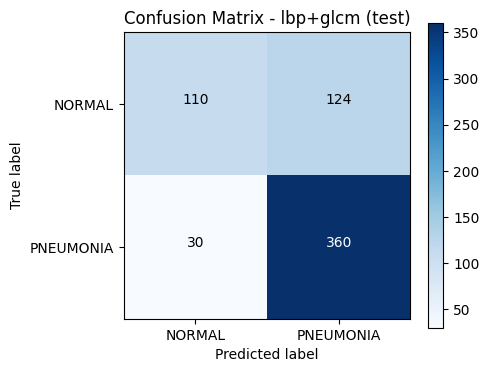

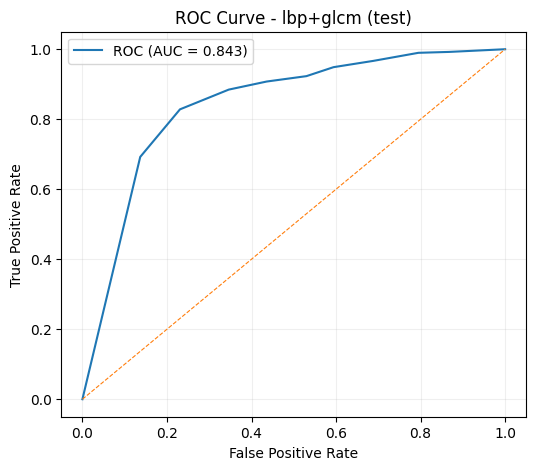


Top 20 features (permutation importance on test):
Feature 75: importance=0.01034
Feature 59: importance=0.00937
Feature 58: importance=0.00881
Feature 61: importance=0.00689
Feature 74: importance=0.00665
Feature 91: importance=0.00657
Feature 24: importance=0.00553
Feature 77: importance=0.00545
Feature 83: importance=0.00537
Feature 67: importance=0.00537
Feature 93: importance=0.00473
Feature 50: importance=0.00417
Feature 49: importance=0.00401
Feature 99: importance=0.00353
Feature 90: importance=0.00337
Feature 11: importance=0.00329
Feature 6: importance=0.00280
Feature 36: importance=0.00272
Feature 69: importance=0.00264
Feature 85: importance=0.00264


=== Procesando combinación: glcm+gabor ===

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores parámetros encontrados: {'knn__n_neighbors': 9, 'selector__k': 72}

--- Metrics (TRAIN (CV)) ---
Accuracy : 0.9093
Precision: 0.9512
Recall   : 0.9254
F1-score : 0.9381
AUC      : 0.9574

--- Metrics (TEST (hold-ou

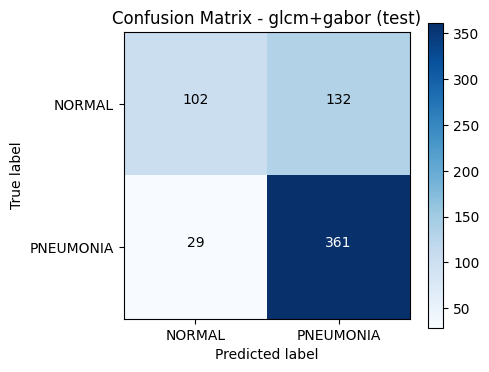

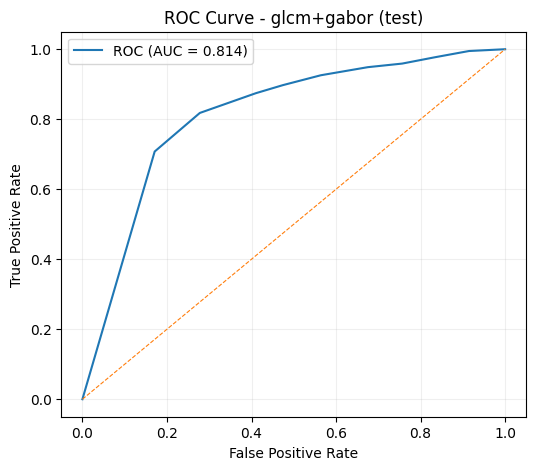


Top 20 features (permutation importance on test):
Feature 5: importance=0.02564
Feature 21: importance=0.02476
Feature 13: importance=0.02099
Feature 29: importance=0.02099
Feature 49: importance=0.01843
Feature 4: importance=0.01803
Feature 25: importance=0.01410
Feature 9: importance=0.01410
Feature 61: importance=0.01314
Feature 37: importance=0.01258
Feature 20: importance=0.01162
Feature 63: importance=0.01138
Feature 7: importance=0.00994
Feature 57: importance=0.00986
Feature 53: importance=0.00946
Feature 28: importance=0.00785
Feature 12: importance=0.00785
Feature 23: importance=0.00681
Feature 45: importance=0.00649
Feature 71: importance=0.00633


=== RESUMEN FINAL ===

-- lbp+glcm --
Best params: {'knn__n_neighbors': 9, 'selector__k': 102}
Confusion matrix:
 [[110 124]
 [ 30 360]]
ROC AUC (test): 0.8426254657023888

-- glcm+gabor --
Best params: {'knn__n_neighbors': 9, 'selector__k': 72}
Confusion matrix:
 [[102 132]
 [ 29 361]]
ROC AUC (test): 0.8140149024764409


In [23]:
def extract_arrays(npz):
    """Extrae X, y, files desde un objeto npz de forma robusta."""
    keys = list(npz.keys())
    X = None; y = None; files = None

    # X candidates
    if 'X' in keys:
        X = npz['X']
    elif 'features' in keys:
        X = npz['features']
    elif 'arr_0' in keys and len(keys) == 1:
        X = npz[keys[0]]
    else:
        # primera matriz 2D que parezca X
        for k in keys:
            if np.ndim(npz[k]) == 2:
                X = npz[k]
                break

    # y candidates
    if 'y' in keys:
        y = npz['y']
    elif 'labels' in keys:
        y = npz['labels']

    # files candidates
    if 'files' in keys:
        files = npz['files']
    elif 'filenames' in keys:
        files = npz['filenames']

    return X, y, files

def generar_lista_k(n_features):
    """Genera lista de k válidos para SelectKBest según n_features."""
    porcentajes = [0.25, 0.50, 0.75, 1.0]
    ks = sorted(set([max(1, int(n_features * p)) for p in porcentajes]))
    ks.append("all")
    return ks

def plot_confusion_matrix(cm, labels, title=None, figsize=(5,4)):
    """Dibuja heatmap simple de la matriz de confusión."""
    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title or "Confusion matrix")
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    # Annotate cells
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

#  RUTAS Y CARGA DE NPZ
base_features = "/content/drive/MyDrive/TareasDigiVision/Clasificación de Imágenes Médicas/results/features"

paths = {
    'lbp_merged_train': os.path.join(base_features, "lbp_merged_train.npz"),
    'lbp_merged_test' : os.path.join(base_features, "lbp_merged_test.npz"),
    'lbp_merged_val'  : os.path.join(base_features, "lbp_merged_val.npz"),
    'glcm_merged_train': os.path.join(base_features, "glcm_merged_train.npz"),
    'glcm_merged_test' : os.path.join(base_features, "glcm_merged_test.npz"),
    'glcm_merged_val'  : os.path.join(base_features, "glcm_merged_val.npz"),
    'gabor_train': os.path.join(base_features, "gabor_train.npz"),
    'gabor_test' : os.path.join(base_features, "gabor_test.npz"),
    'gabor_val'  : os.path.join(base_features, "gabor_val.npz"),
    'contour_train': os.path.join(base_features, "contour_train.npz"),   # opcional si lo quieres
    'contour_test' : os.path.join(base_features, "contour_test.npz"),
    'contour_val'  : os.path.join(base_features, "contour_val.npz"),
}

loaded = {}
for name, p in paths.items():
    if os.path.exists(p):
        loaded[name] = np.load(p)
        print("Loaded:", name)
    else:
        loaded[name] = None
        print("WARNING: missing file:", p)

#- Construir matriz por split
def build_split(feature_objs):
    """
    feature_objs: lista de npz objects del mismo split.
    Devuelve X_concat (horiz), y (vector), files_concat (si hay)
    """
    Xs = []
    ys = None
    files_list = []

    for obj in feature_objs:
        if obj is None:
            raise FileNotFoundError("Falta un npz requerido para la combinación.")
        X, y, files = extract_arrays(obj)
        if X is None:
            raise ValueError("No se pudo extraer X del npz.")
        Xs.append(X)
        if y is not None:
            if ys is None:
                ys = y
            else:
                if not np.array_equal(ys, y):
                    print("WARNING: etiquetas 'y' no coinciden entre archivos; usaré la primera.")
        if files is not None:
            files_list.append(files)

    X_concat = np.concatenate(Xs, axis=1) if len(Xs) > 1 else Xs[0]
    files_concat = np.concatenate(files_list, axis=0) if len(files_list) > 0 else None
    return X_concat, ys, files_concat

# COMBINACIONES A EVALUAR
combos = {
    "lbp+glcm": {
        "train": [loaded['lbp_merged_train'], loaded['glcm_merged_train']],
        "test" : [loaded['lbp_merged_test'],  loaded['glcm_merged_test']],
        "val"  : [loaded['lbp_merged_val'],   loaded['glcm_merged_val']],
    },
    "glcm+gabor": {
        "train": [loaded['glcm_merged_train'], loaded['gabor_train']],
        "test" : [loaded['glcm_merged_test'],  loaded['gabor_test']],
        "val"  : [loaded['glcm_merged_val'],   loaded['gabor_val']],
    }
}

# PIPELINE DE ENTRENAMIENTO/VALIDACIÓN
def run_pipeline(name, split_objs, cv_folds=5, k_neighbors=[3,5,7,9], scoring_for_grid='roc_auc'):
    print("\n\n=== Procesando combinación:", name, "===\n")

    # Construir splits
    X_train, y_train, files_train = build_split(split_objs['train'])
    X_test,  y_test,  files_test  = build_split(split_objs['test'])
    X_val,   y_val,   files_val   = build_split(split_objs['val'])

    if y_train is None:
        raise ValueError("No se encontraron etiquetas 'y' en los npz. Usa archivos merged que contengan 'y'.")

    # Escalado
    scaler = MinMaxScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    X_val_s   = scaler.transform(X_val)

    # Lista dinámica de k
    n_features = X_train.shape[1]
    lista_k = generar_lista_k(n_features)
    # Convertir 'all' a n_features para GridSearch
    lista_k_numeric = [n_features if k == "all" else k for k in lista_k]

    # Pipeline
    pipe = Pipeline([
        ('selector', SelectKBest(score_func=f_classif)),
        ('knn', KNeighborsClassifier())
    ])

    param_grid = {
        'selector__k': lista_k_numeric,
        'knn__n_neighbors': k_neighbors
    }

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    gs = GridSearchCV(pipe, param_grid, scoring=scoring_for_grid, cv=cv, n_jobs=-1, verbose=1)
    gs.fit(X_train_s, y_train)

    print("Mejores parámetros encontrados:", gs.best_params_)
    best = gs.best_estimator_

    # Predicciones CV en training para métricas robustas
    y_train_pred = cross_val_predict(best, X_train_s, y_train, cv=cv)
    y_train_proba = None
    try:
        y_train_proba = cross_val_predict(best, X_train_s, y_train, cv=cv, method='predict_proba')[:,1]
    except Exception:
        y_train_proba = None

    # Evaluación en test (hold-out)
    y_test_pred = best.predict(X_test_s)
    y_test_proba = best.predict_proba(X_test_s)[:,1] if hasattr(best.named_steps['knn'], "predict_proba") else None

    # Métricas impresas
    def print_metrics(y_true, y_pred, y_proba=None, label=""):
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        print(f"\n--- Metrics ({label}) ---")
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1-score : {f1:.4f}")
        if y_proba is not None:
            fpr, tpr, _ = roc_curve(y_true, y_proba)
            roc_auc = auc(fpr, tpr)
            print(f"AUC      : {roc_auc:.4f}")
            return (fpr, tpr, roc_auc)
        else:
            # fallback: use roc_auc_score on predictions if possible
            try:
                roc_auc = roc_auc_score(y_true, y_pred)
                print(f"AUC (from preds): {roc_auc:.4f}")
            except Exception:
                pass
            return None

    roc_train = print_metrics(y_train, y_train_pred, y_train_proba, label="TRAIN (CV)")
    roc_test  = print_metrics(y_test, y_test_pred, y_test_proba, label="TEST (hold-out)")

    # Matriz de confusión y plot
    cm = confusion_matrix(y_test, y_test_pred)
    print("\nConfusion matrix (test):\n", cm)
    plot_confusion_matrix(cm, labels=["NORMAL","PNEUMONIA"], title=f"Confusion Matrix - {name} (test)")

    # ROC plot si hay probabilidades
    if roc_test is not None:
        fpr, tpr, roc_auc = roc_test
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
        plt.plot([0,1],[0,1],'--', linewidth=0.8)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {name} (test)")
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()
    else:
        print("No hay probabilidades para ROC (predict_proba no disponible).")

    # Importancia por permutación sobre test (model-agnostic)
    try:
        ri = permutation_importance(best, X_test_s, y_test, n_repeats=20, random_state=42, n_jobs=-1)
        importances = ri.importances_mean
        top_idx = np.argsort(importances)[::-1][:20]
        print("\nTop 20 features (permutation importance on test):")
        for i in top_idx:
            print(f"Feature {i}: importance={importances[i]:.5f}")
    except Exception as e:
        print("Permutation importance failed:", e)

    return {
        'name': name,
        'best_params': gs.best_params_,
        'confusion_matrix': cm,
        'roc_test': roc_test
    }

# ---------- EJECUTAR pipeline sobre todas las combinaciones ----------
results = {}
for combo_name, split_objs in combos.items():
    try:
        results[combo_name] = run_pipeline(combo_name, split_objs, cv_folds=5, k_neighbors=[3,5,7,9])
    except Exception as e:
        print(f"\nERROR en {combo_name}: {e}")

# ---------- RESUMEN ----------
print("\n\n=== RESUMEN FINAL ===")
for name, res in results.items():
    print("\n--", name, "--")
    if res is None:
        print("No results.")
        continue
    print("Best params:", res.get('best_params'))
    print("Confusion matrix:\n", res.get('confusion_matrix'))
    if res.get('roc_test') is not None:
        print("ROC AUC (test):", res['roc_test'][2])